In [59]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [60]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [61]:
# # Reading Back Data Later
# ##################################################################
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# binary_array_path=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
# def read_ZYX(t,p):
#     with h5py.File(binary_array_path, 'r') as f:
#         # Load the dataset by its name
#         Z_tp = f['Z'][t,p]
#         Y_tp = f['Y'][t,p]
#         X_tp = f['X'][t,p]
#     return Z_tp,Y_tp,X_tp

In [62]:
#CALLING IN TRACKED PARCELS DATA
##################################################################
job_array=False
start_job=500_000;end_job=1_000_000;index_adjust=start_job
parcel=parcel.isel(xh=slice(start_job,end_job))

In [63]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    W = f['W'][:,start_job:end_job]
    Z = f['Z'][:,start_job:end_job]
    Y = f['Y'][:,start_job:end_job]
    X = f['X'][:,start_job:end_job]
    parcel_z=f['z'][:,start_job:end_job]

In [64]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# with h5py.File(dir2+f'LFC_LCL_binary_array.h5', 'r') as f:
#     # Load the dataset by its name
#     LFC = f['LFC'][:]
#     LCL = f['LCL'][:]

# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
open_file=dir2+f'LFC_LCL_binary_array_{res}_{t_res}_{Np_str}.h5'
with h5py.File(open_file, 'r') as f:
    # Load the dataset by its name
    LFC = f['LFC'][:,start_job:end_job]
    LCL = f['LCL'][:,start_job:end_job]

LFC_data=data['lfc'].data

In [72]:
def LoadFinalData(in_file):
    dict = {}
    with h5py.File(in_file, 'r') as f:
        for key in f.keys():
            dict[key] = f[key][:]
    return dict

dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
in_file=dir2+f"parcel_tracking_SUBSET_{res}_{t_res}_{Np_str}"
final_dict=LoadFinalData(in_file)


#DYNAMICALLY CREATING VARIABLES
for key, value in final_dict.items():
    globals()[key] = value

# #DYNAMICALLY PRINTING VARIABLE SIZES
# for key in final_dict:
#     print(f"{key} has {final_dict[key].shape[0]} parcels")

#PRINTING VARIABLE SIZES (ONE BY ONE)
print(f'ALL: {len(ALL_out_arr)} CL parcels and {len(ALL_save_arr)} nonCL parcels')
print(f'SHALLOW: {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')
print(f'DEEP: {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')
print('\n')
print(f'ALL: {len(ALL_SBZ_out_arr)} SBZ parcels and {len(ALL_nonSBZ_out_arr)} nonSBZ parcels')
print(f'SHALLOW: {len(SHALLOW_SBZ_out_arr)} SBZ parcels and {len(SHALLOW_nonSBZ_out_arr)} nonSBZ parcels')
print(f'DEEP: {len(DEEP_SBZ_out_arr)} SBZ parcels and {len(DEEP_nonSBZ_out_arr)} nonSBZ parcels')
print('\n')
print(f'ALL: {len(ALL_ColdPool_out_arr)} ColdPool parcels')
print(f'SHALLOW: {len(SHALLOW_ColdPool_out_arr)} ColdPool parcels')
print(f'DEEP: {len(DEEP_ColdPool_out_arr)} ColdPool parcels')

ALL: 14630 CL parcels and 10991 nonCL parcels
SHALLOW: 10059 CL parcels and 8367 nonCL parcels
DEEP: 1489 CL parcels and 1112 nonCL parcels


ALL: 815 SBZ parcels and 13815 nonSBZ parcels
SHALLOW: 424 SBZ parcels and 9635 nonSBZ parcels
DEEP: 187 SBZ parcels and 1302 nonSBZ parcels


ALL: 13815 ColdPool parcels
SHALLOW: 9635 ColdPool parcels
DEEP: 1302 ColdPool parcels


In [73]:
#APPLYING JOB_ARRAY TO PARCEL NUMBER
####################################
def job_filter(arr):
    return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]


print('Applying Job Array')
var_names = [
    'ALL_out_arr', 'ALL_save_arr', 'SHALLOW_out_arr', 'SHALLOW_save_arr', 'DEEP_out_arr', 'DEEP_save_arr',
    'ALL_SBZ_out_arr', 'ALL_nonSBZ_out_arr', 'SHALLOW_SBZ_out_arr', 'SHALLOW_nonSBZ_out_arr',
    'DEEP_SBZ_out_arr', 'DEEP_nonSBZ_out_arr',
    'ALL_ColdPool_out_arr', 'SHALLOW_ColdPool_out_arr', 'DEEP_ColdPool_out_arr'
]

for name in var_names:
    globals()[name] = job_filter(globals()[name])
print('done')

Applying Job Array
done


In [51]:
####################################################################################################
#PLOTTING TRAJECTORIES

In [87]:
out_arr=ALL_out_arr
# out_arr=SHALLOW_out_arr
out_arr=DEEP_out_arr

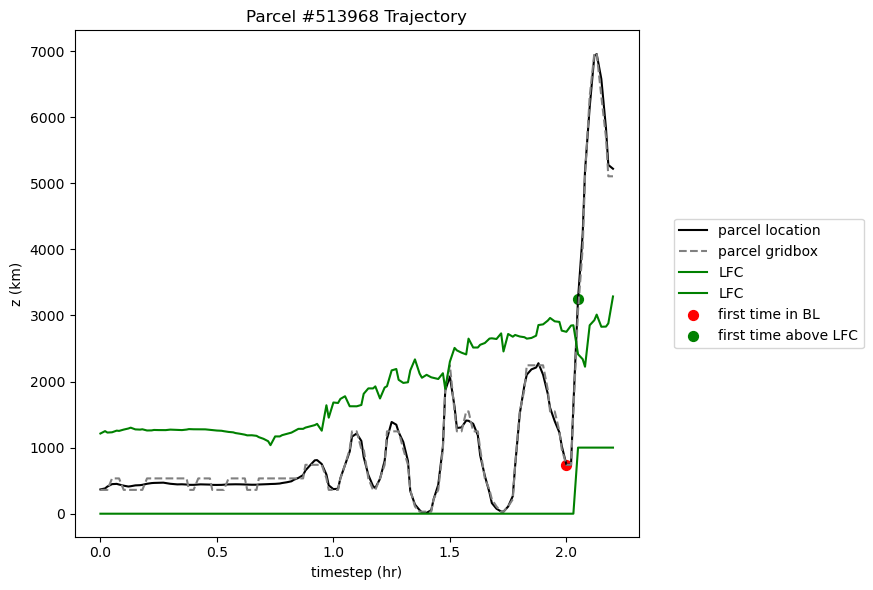

In [94]:


def TrajectoryPlot(i):
    
    # Assuming 'data', 'ALL_out_arr', 'parcel', 'LFC_data', 'Z', 'T', 'Y', 'X', etc., are already defined
    
    # Define grid for the plot and legend
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[0.85, 0.15])  # 1 row, 2 columns, second column is smaller for legend
    
    # Define the first subplot for the trajectory plot
    ax1 = plt.subplot(gs[0])
    
    # Define time steps and other data
    num_mins=1 #5
    tsteps = np.arange(len(data['time'])) * num_mins / 60
    tsteps = np.round(tsteps, 2)
    
    p = out_arr[i, 0]
    t1 = out_arr[i, 1]
    t2 = out_arr[i, 2]
    
    z1 = parcel_z[t1, p-index_adjust]
    z2 = parcel_z[t2, p-index_adjust]
    
    zs = parcel_z[:, p-index_adjust]
    zgrids = data['zh'][Z[:, p-index_adjust]] * 1000
    
    ts=np.arange(len(parcel['time']))
    lfcs = LFC_data[ts, Y[:, p-index_adjust], X[:, p-index_adjust]]
    lfcs2 = LFC[:,p-index_adjust]*1000; #print(lfcs)
    
    
    # Plot parcel trajectory, grid, and LFC
    ax1.plot(tsteps, zs, color='black', label='parcel location')
    ax1.plot(tsteps, zgrids, linestyle='dashed', color='grey', label='parcel gridbox')
    ax1.plot(tsteps, lfcs, color='green', label='LFC')
    ax1.plot(tsteps, lfcs2, color='green', label='LFC')
    ax1.scatter(t1 * num_mins / 60, z1, color='red', s=50, label='first time in BL')
    ax1.scatter(t2 * num_mins / 60, z2, color='green', s=50, label='first time above LFC')
    
    # Labels and title
    ax1.set_xlabel('timestep (hr)')
    ax1.set_ylabel('z (km)')
    ax1.set_title(f'Parcel #{p} Trajectory')
    
    # Set up legend in the second subplot (outside of the plot)
    # Adjusting bbox_to_anchor to move legend outside
    ax1.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=10)
    
    # Adjust layout to prevent overlap
    fig.tight_layout()
    
    # Show the plot
    plt.show()

# i=1
i+=1
TrajectoryPlot(i)

In [57]:
parcel_z.shape

(133, 500000)

In [ ]:
#######################################

In [ ]:
#VARIABLE TRAJECTORIES (OLD)
##################################################################

In [ ]:
##OLD

# #VARIABLES AND GET UNITED FUNCTION
# variables = data.variables
# long_names = {var: {
#         'long_name': data[var].attrs.get('long_name', ''),
#         'units': data[var].attrs.get('units', '')
#     } for var in variables}


# w_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('wb') or var in ['w']}
# ptb_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('ptb') or var in ['th']}
# qvb_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('qvb') or var in ['qv']}
# vars = {}
# vars.update(w_vars)
# vars.update(ptb_vars)
# vars.update(qvb_vars)

# var_names=list(vars.keys())
# long_names = [info['long_name'] for info in vars.values()]
# units = [info['units'] for info in vars.values()]
# def convert_to_latex(unit):
#     parts = unit.split('/')  # Split the unit into parts
#     latex_unit = parts[0]  # Start with the first part
#     for part in parts[1:]:  # Iterate over the remaining parts
#         latex_unit += r"\ " + part + r"^{-1}"  # Add the part with a '^{-1}' exponent
#     return r"$" + latex_unit + r"$"
# latex_units = [convert_to_latex(unit) for unit in units]

# var_names.append("qv'")
# long_names.append('perturbation water vapor mixing ratio')
# latex_units.append(r'$kg\ kg^{-1}')

# var_names.append("th'")
# long_names.append('perturbation theta')
# latex_units.append(r'$K')

# def get_unit(var,var_names):
#     where=np.where(np.array(var_names)==var)[0]
#     final_unit=np.array(latex_units)[where][0]
#     if ('wb' in var) or ('qvb' in var) or ('thb' in var) or ("'" in var):
#         final_unit+=' /1000'
#     return final_unit

In [ ]:
# #PLOTTING FUNCTION
# def plot_variable(var_box_interp, var, Ng, var_names):
#     def add_grid(Ng,ax):
#         # #adding grid lines
#         # ygrids=np.arange(0,(Ng-1),0.5)
#         # xgrids=np.arange(0,(Ng-1),0.5)
#         ywhich=np.linspace(0,(Ng-1),Ng+1)
#         xwhich=np.linspace(0,(Ng-1),Ng+1)
       
#         # ywhich=ygrids[np.where((ygrids % 1) == 0.5)]
#         # xwhich=xgrids[np.where((xgrids % 1) == 0.5)]
        
#         for (xind, yind) in zip(xwhich, ywhich):
#             ax.axhline(yind, color='white',linestyle='--',label=None) #add grid
#             ax.axvline(xind, color='white',linestyle='--',label=None) #add grid
    
#     # Create figure and main gridspec (1 row, 3 columns)
#     fig = plt.figure(figsize=(14, 6),constrained_layout=False)
#     gs = GridSpec(1, 3, width_ratios=[2, 0.1, 1.5], figure=fig, wspace=0.3)  # Reduce space between left and middle panel
    
#     # Create a 3x3 gridspec within the left panel
#     gs_left = GridSpecFromSubplotSpec(3, 3, subplot_spec=gs[0, 0], wspace=0.1, hspace=0.2)
#     # gs_left=gs[0].subgridspec(3, 3, wspace=0, hspace=0)
    
#     # Loop over timesteps and create subplots in 3x3 format (left to right, top to bottom)
    
#     if var=='qv':
#         cmap='Blues'
#     elif var=="qv'":
#         cmap='RdBu_r'
#     else:
#         cmap='viridis' #cmap='RdBu_r'
    
#     n_levels=30
#     vmin=var_box_interp.min();vmax=var_box_interp.max()#;vmin=-vmax
#     levels = np.linspace(vmin, vmax, n_levels)
#     # import matplotlib.colors as mcolors
#     # # norm = Normalize(vmin=vmin, vmax=vmax)
#     # norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=n_levels)
#     # cmap = plt.get_cmap(cmap, n_levels)
    
#     for t in range(9):
#         row, col = divmod(t, 3)  # Get row, column indices for 3x3 layout
#         ax = fig.add_subplot(gs_left[row, col])
#         im = ax.contourf(var_box_interp[t],cmap=cmap,levels=levels,vmin=vmin,vmax=vmax)#,norm=norm)
#         add_grid(Ng,ax)
#         ax.set_title(f't = {t-1}', fontsize=10)
            
#         ax.set_xticks(range(var_box_interp.shape[2]))
#         ax.set_yticks(range(var_box_interp.shape[1]))    
#         ax.set_xlabel('x (km)');ax.set_ylabel('y (km)')
        
#         # ax.set_xticks(np.arange(-2, 3)) 
#         # ax.set_yticks(np.arange(-2, 3))
        
#         # Hide major tick labels selectively (not the ticks themselves)
#         if col != 0:
#             ax.set_yticklabels([])
#             ax.set_ylabel('')
#         if row != 2:
#             ax.set_xticklabels([])
#             ax.set_xlabel('')
    
        
    
#     # Middle panel: Create a subplot for the colorbar
#     ax_cbar = fig.add_subplot(gs[0, 1])  # Use the middle narrow panel
#     cbar = fig.colorbar(im, cax=ax_cbar)
#     cbar.ax.yaxis.set_ticks_position('left')
#     # ax_cbar.set_title(label=get_unit(var,var_names), fontsize=10)
    
#     # Right panel placeholder
#     ax_right = fig.add_subplot(gs[0, 2])
#     ax_right.set_title(f"{var} over Avg CL-LFC Trajectory")
    
#     ax_right.plot(var_box_interp[:,2,2],color='black');
#     ax_right.set_ylabel(get_unit(var,var_names))
#     ax_right.set_xlabel(f'timesteps (5 mins)')

#     fig.show()
#     return fig

In [ ]:
# def save_plot(fig, filename, dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/plots/'):
#     # Ensure the directory exists
#     if not os.path.exists(dir):
#         os.makedirs(dir)

#     # Construct the full file path
#     file_path = os.path.join(dir, filename)

#     # Save the figure to the file
#     fig.savefig(file_path, dpi=300)
#     print(f"plot saved")

In [ ]:
##OLD
#  # t_mean=int(np.floor(np.mean(out_arr[:,2]+after+1-(out_arr[:,1]+1))))
# t_mean=9
# Nx=len(data['xh'])
# Ny=len(data['yh'])

# box_size = 2
# Ng = 2*box_size+1
        
# def get_var(var,t_val,z_val,y_slice,x_slice):
#     if var in  np.array(list(w_vars.keys())):
#         var_data=data[var].isel(time=t_val,
#                                 yh=y_slice, xh=x_slice).interp(zf=data['zh']).isel(zh=z_val)
#     elif var=="qv'" or var=="th'":
#         var_data=data['qv'].isel(time=t_val,zh=z_val)
#         var_data-=var_data.mean(dim=('yh','xh'))
#         var_data=var_data.isel(yh=y_slice,xh=x_slice)
#     else:
#         var_data=data[var].isel(time=t_val,zh=z_val,yh=y_slice,xh=x_slice)

#     if ('wb' in var) or ('qvb' in var) or ('thb' in var) or ("'" in var):
#         var_data*=1000
#     return var_data
    
# def get_trajectory(var,row):
#     #SETUP
#     ######
#     out_arr=ALL_out_arr
#     box_size = 2
#     Ng = 2*box_size+1
#     # after=4 #20 mins
#     after=0 #TESTING***
    
#     #GETTING INDICES
#     ################
#     p=out_arr[row,0]
#     t1=out_arr[row,1]
#     t2=out_arr[row,2]
    
#     ts=np.arange(t1-1,t2+after+1)

#     # zs=Z[ts,p]
#     # ys=Y[ts,p]
#     # xs=X[ts,p]

#     [zs,ys,xs]=read_ZYX(ts,p) #NEW
    
#     #MAKING DATA
#     ############
#     var_box=np.zeros((len(ts),Ng,Ng))

#     # Skip parcels that cross the boundary
#     if np.any((ys - box_size < 0) | (ys + box_size >= Ny) | 
#           (xs - box_size < 0) | (xs + box_size >= Nx)):
#         raise ValueError('Crossed Boundary')
        
#     # Loop through each (xs, ys) pair and slice the data
#     for i in range(len(ts)):
#         # Extract the variable for the valid parcel
#         var_box[i] = get_var(
#             var,
#             ts[i],
#             zs[i], 
#             slice(ys[i] - box_size, ys[i] + box_size + 1), 
#             slice(xs[i] - box_size, xs[i] + box_size + 1)
#         )
    
#     #TIME INTERPOLATION
#     ####################
#     # Create interpolation function along axis 0 (time)
#     interp_func = interp1d(np.linspace(0, 1, var_box.shape[0]), var_box, axis=0, kind='linear', fill_value='extrapolate')
    
#     # Interpolate to new time steps
#     var_box_interp = interp_func(np.linspace(0, 1, t_mean))
    
#     return var_box,var_box_interp

# print(var_names)
# var=var_names[10]
# row=10;[var_box1,var_box_interp1]=get_trajectory(var=var,row=row)
# #PLOTTING
# fig=plot_variable(var_box_interp1, var, Ng, var_names)
# #SAVING
# save_plot(fig=fig,filename=f"Parcel_{row}_Trajectory_{var}_{res}")


In [ ]:
# #######################################################################
# RUNNING FOR MEAN OF ALL TRACKED TRAJECTORY (OLD)

In [ ]:
# # t_mean=int(np.floor(np.mean(out_arr[:,2]+after+1-(out_arr[:,1]+1))))
# t_mean=9
# Nx=len(data['xh'])
# Ny=len(data['yh'])
# def get_var(var,t_val,z_val,y_slice,x_slice):
#     if var in  np.array(list(w_vars.keys())):
#         var_data=data[var].isel(time=t_val,
#                                 yh=y_slice, xh=x_slice).interp(zf=data['zh']).isel(zh=z_val)
#     elif var=="qv'" or var=="th'":
#         var_data=data['qv'].isel(time=t_val,zh=z_val)
#         var_data-=var_data.mean(dim=('yh','xh'))
#         var_data=var_data.isel(yh=y_slice,xh=x_slice)
#     else:
#         var_data=data[var].isel(time=t_val,zh=z_val,yh=y_slice,xh=x_slice)

#     if ('wb' in var) or ('qvb' in var) or ('thb' in var) or ("'" in var):
#         var_data*=1000
#     return var_data

# #SETUP
# ######
# # out_arr=ALL_out_arr
# # out_arr=SHALLOW_out_arr
# out_arr=DEEP_out_arr
# box_size = 2
# Ng = 2*box_size+1
# # after=4 #20 mins
# after=0
# def get_mean_trajectory(var):
#     var_box_interp=np.zeros((t_mean,Ng,Ng))

#     for row in np.arange(out_arr.shape[0]):
#         if np.mod(row,10)==0: print(f'current row {row}')
        
#         #GETTING INDICES
#         ################
#         p=out_arr[row,0]
#         t1=out_arr[row,1]
#         t2=out_arr[row,2]
        
#         ts=np.arange(t1-1,t2+after+1)
#         # zs=Z[ts,p]
#         # ys=Y[ts,p]
#         # xs=X[ts,p]

#         [zs,ys,xs]=read_ZYX(ts,p) #NEW
        
#         #MAKING DATA
#         ############
#         var_box=np.zeros((len(ts),Ng,Ng))
    
#         # Skip parcels that cross the boundary
#         if np.any((ys - box_size < 0) | (ys + box_size >= Ny) | 
#               (xs - box_size < 0) | (xs + box_size >= Nx)):
#             continue
            
#         # Loop through each (xs, ys) pair and slice the data
#         for i in range(len(ts)):
#             # Extract the variable for the valid parcel
#             var_box[i] = get_var(
#                 var, 
#                 ts[i],
#                 zs[i],
#                 slice(ys[i] - box_size, ys[i] + box_size + 1), 
#                 slice(xs[i] - box_size, xs[i] + box_size + 1))
            
#         #TIME INTERPOLATION
#         ####################
#         # Create interpolation function along axis 0 (time)
#         interp_func = interp1d(np.linspace(0, 1, var_box.shape[0]), var_box, axis=0, kind='linear', fill_value='extrapolate')
        
#         # Interpolate to new time steps
#         var_box_interp += interp_func(np.linspace(0, 1, t_mean))

#     var_box_interp/=out_arr.shape[0]
#     return var_box_interp

# var="w"
# var_box_interp2=get_mean_trajectory(var=var)
# fig=plot_variable(var_box_interp2, var, Ng, var_names)
# save_plot(fig=fig,filename=f"Mean_Trajectory_{var}_{res}")

# # for var in var_names:
# #     print(var)
# #     var_box_interp2=get_mean_trajectory(var=var)
# #     #PLOTTING
# #     fig=plot_variable(var_box_interp2, var, Ng, var_names)
# #     save_plot(fig=fig,filename=f"Mean_Trajectory_{var}_{res}")

In [ ]:
#######################################

In [ ]:
# # Reading Back Data Later
# ##################################################################
# #DOMAIN SUBSETTING
# def DOMAIN_SUBSET(out_arr):
#     print(f'length before: {len(out_arr)}')

#     #SETTING UP
#     ###########
#     ocean_percent=2/8
#     left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
#     where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
#     where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
#     end_xh=len(data['xh'])-1-50
#     end_xf=len(data['xf'])-1-50
    
#     print(f'x in {0}:{where_coast_xh-1} FOR SEA')
#     print(f'x in {where_coast_xh}:{end_xh} FOR LAND')

#     if res=='1km':
#         t_start=36 
#     elif res=='250m':
#         t_start=36*5 
#     t_end=len(data['time']) 
#     print(f't in {t_start}:end (8 hours)')

#     #SUBSETTING CODE
#     ################
#     t,p=out_arr[:,1],out_arr[:,0]
#     if 'job_array' in globals():
#         p -= index_adjust

#     #GETTING X VALUES OF EACH PARCEL 
#     fancy_index=True
#     # fancy_index=False
#     if fancy_index==True:
#         xs=X[t,p] #FANCY INDEXING
#     elif fancy_index==False: #(slightly longer, but avoids loading X into memory)
#         dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
#         in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
#         with h5py.File(in_file, 'r') as f:
#             xs=[]
#             for i, j in zip(t, p):
#                 xs.append(f['X'][i, j])
#             xs=np.array(xs)
#     ################
    
#     out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
#     out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

#     print(f'==> length after: {len(out_arr)}'+'\n')
#     return out_arr

In [1]:
#SOME BACKUP ITEMS (OLD)
####################################################################################################
#READING OUTPUT

In [ ]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# open_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
# with h5py.File(open_file, 'r') as f:
#     # Load the dataset by its name

#     W = f['W'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

In [ ]:
# #DOMAIN SUBSETTING
# def DOMAIN_SUBSET(out_arr):
#     print(f'length before: {len(out_arr)}')

#     ocean_percent=2/8
#     left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
#     where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
#     where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
#     end_xh=len(data['xh'])-1-50
#     end_xf=len(data['xf'])-1-50
    
#     print(f'x in {0}:{where_coast_xh-1} FOR SEA')
#     print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
#     # t_end=78 
#     # if res=='250m':t_end=410
#     # print(f't in {0}:{t_end} (6.5 hours)')
#     t_start=36 
#     t_end=len(data['time'])
#     print(f't in {t_start}:end (8 hours)')

#     #SUBSETTING CODE
#     xs=X[list(out_arr[:,1]),list(out_arr[:,0])]
    
#     out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
#     out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

#     print(f'length after: {len(out_arr)}')
#     return out_arr

In [ ]:

# open_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{t_res}_{Np_str}.nc'

# out=xr.open_dataset(open_file)['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
# save=xr.open_dataset(open_file)['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

# out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
# save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

# ###############################################################################
# #remove duplicates
# lst=[]
# unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
# for elem in duplicates:
#     idx = np.where(out_arr[:,0] == elem)[0] 
#     extras=idx[np.where(out_arr[idx,2]!=np.min(out_arr[idx,2]))]
#     lst.extend([x for x in extras])
# mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
# out_arr=out_arr[mask]; 
# ###############################################################################

# out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
# save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
# placeholder=out_arr.copy(); run=True
# ############################################################
# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

# ############################################################
# #SUBSETTING
# subset=True
# if subset==True:
#     out_arr=DOMAIN_SUBSET(out_arr)
#     save_arr=DOMAIN_SUBSET(save_arr)
# ############################################################

# ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

In [ ]:
# #SHALLOW
# parcel_z=parcel['z'].data

# def ddt(f,dt=1):
#     ddx = (
#             f[1:  ]
#             -
#             f[0:-1]
#         ) / (
#         2 * dt
#     )
#     return ddx

# #search for deep convective parcels within lagrangian tracking output     
# ##############################################################
# def SHALLOW_threshold(zthresh,type):

#     if type=='CL':
#         out_arr=ALL_out_arr.copy()
#     elif type=='nonCL':
#         out_arr=ALL_save_arr.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
#         elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)
# ##############################################################

# convectivelevel=4 #4km
# SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
# SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

# print('list of first 10 SBZ parcels'); print(out_arr[:15])
# print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

In [ ]:
# #DEEP
# parcel_z=parcel['z'].data

# #search for deep convective parcels within lagrangian tracking output     
# ##############################################################
# def DEEP_threshold(zthresh,type):
#     if type=='CL':
#         out_arr=ALL_out_arr.copy()
#     elif type=='nonCL':
#         out_arr=ALL_save_arr.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
        
#         if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)
# ##############################################################

# convectivelevel=6 #4km
# DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
# DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

# print('list of first 10 SBZ parcels'); print(out_arr[:15])
# print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

In [ ]:
# #FINDING SBZ CONVERGENCE
# parcel_z=parcel['z'].data

# #FIND ALL X MAXES
# import sys
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# path=dir+'../Functions'
# sys.path.append(path)
# # import inspect
# # functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# # functions

# # TF=False
# # if TF==False:
# #     print('Loading In Data')
# #     u_data=data['u'].interp(xf=data['xh']).data
# #     v_data=data['v'].interp(yf=data['yh']).data
# #     TF=True


# from NumericalFunctions import *
# def find_SBZ_xmaxs():
    
#     # print('calculating convergence and taking mean')
#     # Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
#     dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{t_res}' + '.h5'
#     with h5py.File(file_path, 'r') as f:
#         Conv = f['conv'][:]
    
#     zlev=4
#     Conv_ymean=np.mean(Conv[:,zlev],axis=1)
#     xmaxs=np.argmax(Conv_ymean, axis=1)

#     return xmaxs
# def find_SBZ_xmaxs():
#     # Define the directory and file path
#     dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{t_res}' + '.h5'
    
#     # Open the HDF5 file in read mode
#     with h5py.File(file_path, 'r') as f:
#         # Access the 'conv' dataset
#         conv_dataset = f['conv']
        
#         # Define the vertical level you are interested in
#         zlev = 4
        
#         # Initialize a list to store the xmaxs for each time step
#         xmaxs_list = []

#         # Loop over each time step (axis=0 corresponds to time)
#         for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
#             # Read the relevant slice for this time step and vertical level
#             Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
#             # Calculate the mean across the y-axis
#             Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
#             # Find the index of the maximum value along the x-axis
#             xmax = np.argmax(Conv_ymean)
            
#             # Append the result for this time step
#             xmaxs_list.append(xmax)
    
#     # Convert the list of xmaxs to a numpy array (optional)
#     xmaxs = np.array(xmaxs_list)

#     return xmaxs #returns SBZ x location for each timestep


# def subset_SBZ(out_arr):
#     xmaxs=find_SBZ_xmaxs()

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_arr.shape[0]):
        
#         row=out_arr[ind]
#         p=row[0]
#         t=row[1]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_arr=out_arr[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_arr.shape[0])
#     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
#     return SBZ_out_arr,nonSBZ_out_arr


# # #LOADING CL MAXS FROM CL TRACKING ALGORITHM
# # folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# # whereSBZ=xr.open_dataset(folder+f'whereCL_{res}_{t_res}_ONLY_SBZS.nc').load()
# # whereSBZ=whereSBZ.isel(time=slice(0,len(data['time'])))
# # whereSBZ=whereSBZ['maxconv_x']
# # def Get_SBZ_X(t,z,y):
# #     Conv_X_Max=whereSBZ[t,z,y,:].values
# #     return Conv_X_Max
# # def subset_SBZ(out_arr):

# #     SBZ_subset=[]
# #     # test=[] #TESTING
    
# #     for ind in np.arange(out_arr.shape[0]):
        
# #         row=out_arr[ind]
# #         p=row[0]
# #         t=row[1]

# #         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
# #         value=X[t,p]
# #         if np.any((value >= xmaxs - 2*kms) & (value <= xmaxs + 2*kms))==True:
# #             SBZ_subset.append(ind)
# #             # test.append(p) #TESTING
    
# #     SBZ_out_arr=out_arr[SBZ_subset]
# #     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

# #     valid_range=np.arange(out_arr.shape[0])
# #     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
# #     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
# #     return SBZ_out_arr,nonSBZ_out_arr

# #SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
# def SHALLOW_threshold(zthresh,type):
#     if type=='SBZ':
#         out_arr=ALL_SBZ_out_arr.copy()
#     elif type=='nonSBZ':
#         out_arr=ALL_nonSBZ_out_arr.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
        
#         if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)

# def DEEP_threshold(zthresh,type):
#     if type=='SBZ':
#         out_arr=ALL_SBZ_out_arr.copy()
#     elif type=='nonSBZ':
#         out_arr=ALL_nonSBZ_out_arr.copy()

#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 
        
#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
        
#         if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)
# ##############################################################
# [ALL_SBZ_out_arr,ALL_nonSBZ_out_arr]=subset_SBZ(ALL_out_arr)
# SHALLOW_SBZ_out_arr=SHALLOW_threshold(4,'SBZ')
# print(f'there are a total of {len(SHALLOW_SBZ_out_arr)} SHALLOW SBZ CL parcels')
# SHALLOW_nonSBZ_out_arr=SHALLOW_threshold(4,'nonSBZ')
# print(f'there are a total of {len(SHALLOW_nonSBZ_out_arr)} SHALLOW nonSBZ CL parcels')
# DEEP_SBZ_out_arr=DEEP_threshold(6,'SBZ')
# print(f'there are a total of {len(DEEP_SBZ_out_arr)} DEEP SBZ CL parcels')
# DEEP_nonSBZ_out_arr=DEEP_threshold(6,'nonSBZ')
# print(f'there are a total of {len(DEEP_nonSBZ_out_arr)} DEEP nonSBZ CL parcels')

In [ ]:
#######################################
#NEWER OLD THINGS

In [ ]:
# ##OLD

########################################################################
#RUNNING FOR ONE VARIBLE TRAJECTORY ONLY
# # Reading Back Data Later
# ##############
# def make_data_dict(var_names,read_type):
#     if read_type=='h5py':
#         with h5py.File(in_file, 'r') as f:
#             data_dict = {var_name: f[var_name][:] for var_name in var_names}
            
#     elif read_type=='xarray':
#         in_data = xr.open_dataset(
#             in_file,
#             engine='h5netcdf',
#             phony_dims='sort',
#             chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
#         )
#         data_dict = {k: in_data[k][:].compute().data for k in var_names}
#     return data_dict

# # read_type='xarray'
# read_type='h5py'
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
# in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

# var_names = ['Z', 'Y', 'X']
# data_dict = make_data_dict(var_names,read_type)
# Z, Y, X = (data_dict[k] for k in var_names)

# def read_ZYX(ts,p):
#     return Z[ts,p],Y[ts,p],X[ts,p]

In [ ]:
# #TESTING
# def load_file():
#     in_file=dir+f'Project_Algorithms/Tracking_Algorithms/parcel_tracking_{res}_{t_res}_{Np_str}.h5'
#     with h5py.File(in_file, 'r') as hf:
#         out_arr=hf['out_arr'][:]
#         save_arr=hf['save_arr'][:]
#         # save2_arr=hf['save2_arr'][:]
#     return out_arr,save_arr
# [out_arr,save_arr]=load_file()

# out_arr=out_arr[np.where(out_arr[:,1]!=0)] #FOR NC
# save_arr=save_arr[np.where(save_arr[:,1]!=0)] #FOR NC

# print('list of first 10 ignored parcels');
# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels'+'\n')

In [ ]:
# #LOADING BACK IN
# def load_file():
#     in_file=dir+f'Project_Algorithms/Tracking_Algorithms/parcel_tracking_{res}_{t_res}_{Np_str}.h5'
#     with h5py.File(in_file, 'r') as hf:
#         out_arr=hf['out_arr'][:]
#         save_arr=hf['save_arr'][:]
#         save2_arr=hf['save2_arr'][:]
#     return out_arr,save_arr,save2_arr
# [out_arr,save_arr,save2_arr]=load_file()

# print('list of first 10 ignored parcels');
# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels'+'\n')

# if 'job_array' in globals():
#     #APPLYING JOB_ARRAY TO PARCEL NUMBER
#     ####################################
#     def job_filter(arr):
#         return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]
#     print('Applying Job Array')
#     out_arr=job_filter(out_arr)
#     save_arr=job_filter(save_arr)

# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels'+'\n')

# #CHOOSING UNIQUE INDEXES
# ###############################################################################
# def remove_duplicates(arr):
#     lst = []
#     unique_values, counts = np.unique(arr[:, 0], return_counts=True)
#     duplicates = unique_values[counts > 1]
#     for elem in duplicates:
#         idx = np.where(arr[:, 0] == elem)[0]
#         extras = idx[np.where(arr[idx, 1] != np.min(arr[idx, 1]))]
#         lst.extend(extras)
#     mask = np.ones(len(arr), dtype=bool)
#     mask[lst] = False
#     return arr[mask]
# out_arr=remove_duplicates(out_arr)
# save_arr=remove_duplicates(save_arr)
# ###############################################################################

# ############################################################
# #SUBSETTING
# subset=True
# if subset==True:
#     out_arr=DOMAIN_SUBSET(out_arr)
#     save_arr=DOMAIN_SUBSET(save_arr)
# ############################################################

# ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

In [ ]:
# #OLD BACKUP 
# #LOADING BACK IN
# def load_file():
#     in_file=dir+f'Project_Algorithms/Tracking_Algorithms/parcel_tracking_{res}_{t_res}_{Np_str}.h5'
#     with h5py.File(in_file, 'r') as hf:
#         out_arr=hf['out_arr'][:]
#         save_arr=hf['save_arr'][:]
#         save2_arr=hf['save2_arr'][:]
#     return out_arr,save_arr,save2_arr
# [out_arr,save_arr,save2_arr]=load_file()

# save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];

# ###############################################################################
# #remove duplicates
# lst=[]
# unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
# for elem in duplicates:
#     idx = np.where(out_arr[:,0] == elem)[0] 
#     extras=idx[np.where(out_arr[idx,2]!=np.min(out_arr[idx,2]))]
#     lst.extend([x for x in extras])
# mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
# out_arr=out_arr[mask]; 
# ###############################################################################

# print('list of first 10 ignored parcels');print(save_arr[:5])
# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

# ############################################################
# #SUBSETTING
# subset=True
# if subset==True:
#     out_arr=DOMAIN_SUBSET(out_arr)
#     save_arr=DOMAIN_SUBSET(save_arr)
# ############################################################

# ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

In [ ]:
# #SHALLOW
# parcel_z=parcel['z'].data #EXTRA

# def ddt(f,dt=1):
#     ddx = (
#             f[1:  ]
#             -
#             f[0:-1]
#         ) / (
#         2 * dt
#     )
#     return ddx

# #search for deep convective parcels within lagrangian tracking output     
# ##############################################################
# def SHALLOW_threshold(zthresh,type):

#     if type=='CL':
#         out_arr=ALL_out_arr.copy()
#     elif type=='nonCL':
#         out_arr=ALL_save_arr.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
#         elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)
# ##############################################################

# convectivelevel=4 #4km
# SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
# SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

# print('list of first 10 SBZ parcels'); print(out_arr[:15])
# print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

In [ ]:
# #DEEP
# # parcel_z=parcel['z'].data #EXTRA

# #search for deep convective parcels within lagrangian tracking output     
# ##############################################################
# def DEEP_threshold(zthresh,type):
#     if type=='CL':
#         out_arr=ALL_out_arr.copy()
#     elif type=='nonCL':
#         out_arr=ALL_save_arr.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_arr)): 
#         if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
#         #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

#         #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
#         #Takes The time derivative 
#         ddx=ddt(above)

#         #Checks whether the Local Time Max Is Located Above zthresh
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
        
#         if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)

#     #SUBSET OUT FOR FINAL RESULT
#     out_arr=out_arr[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
#     return out_arr#, extendrange
#     # print(out_arr)
# ##############################################################

# convectivelevel=6 #4km
# DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
# DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

# print('list of first 10 SBZ parcels'); print(out_arr[:15])
# print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')